In [5]:
import numpy as np                                    
import pandas as pd                                    
import geopandas as gpd                                 
import matplotlib.pyplot as plt                         
from sklearn.neighbors import KNeighborsRegressor        
from sklearn.model_selection import train_test_split     
%matplotlib inline                                       

In [8]:
gpd.options.io_engine = "pyogrio" #faster engine

rf= r"C:/Projects/GeoChem-DataLab/raw_data/markgeokemi_regional.gpkg"

raw = gpd.read_file(
    rf,
    layer = "moran_0063mm_hno3_icpms", 
    use_arrow = True
)
#Drop rows with missing ID/coordinates, ensure SWEREF system 
df_clean = raw.dropna(   
    subset=[
        "unikt_id", "ns", "ew", "geometry"
    ]).set_crs("EPSG:3006", allow_override=True) # confirm SWEREF99 TM (per SGU source, EPSG:3006)
#]).set_crs("EPSG:3006")  # only works if data has no CRS yet — will error if already set

# save cleaned data to GeoPackage
df_clean.to_file(
     "C:/Projects/GeoChem-DataLab/cleaned_data/df_clean.gpkg",
    driver= "GPKG",
    use_arrow = True # faster write
) # save cleaned data to disk as checkpoint

# Filter: keep only rows with valid, positive As/Fe/Ca/Al/U
# (0 = "not analyzed" per SGU product description; excluded by > 0)
# --------------------------------------------------------------
df_markgeodata = df_clean[
    (df_clean["as_ppm"].notna()) & (df_clean["as_ppm"] > 0) &   # As: valid, positive only
    (df_clean["fe_ppm"].notna()) & (df_clean["fe_ppm"] > 0) &   # Fe: valid, positive only
    (df_clean["ca_ppm"].notna()) & (df_clean["ca_ppm"] > 0) &   # Ca: valid, positive only
    (df_clean["al_ppm"].notna()) & (df_clean["al_ppm"] > 0) &   # Al: valid, positive only
    (df_clean["u_ppm"].notna())  & (df_clean["u_ppm"] > 0)      # U: valid, positive only
][[
    "unikt_id", "ns", "ew",
    "as_ppm", "fe_ppm", "ca_ppm", "al_ppm", "u_ppm",
    "geometry"]].copy()  # keep only needed columns; independent copy

print(f"Analysis-ready sample points: {len(df_markgeodata)}")  # expect ~28,470

# Relative screening: 75th and 95th percentile thresholds
# --------------------------------------------------------------
as_p75 = df_markgeodata["as_ppm"].quantile(0.75)
as_p95 = df_markgeodata["as_ppm"].quantile(0.95)

u_p75 = df_markgeodata["u_ppm"].quantile(0.75)
u_p95 = df_markgeodata["u_ppm"].quantile(0.95)

print(f"As: 75th = {as_p75:.2f} ppm, 95th = {as_p95:.2f} ppm")
print(f"U:  75th = {u_p75:.2f} ppm, 95th = {u_p95:.2f} ppm")


C:\Users\Admin\anaconda3\Lib\site-packages\pyogrio\geopandas.py:346: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["geometry"] = shapely.from_wkb(wkb_values, on_invalid=on_invalid)


Analysis-ready sample points: 27981
As: 75th = 3.90 ppm, 95th = 13.00 ppm
U:  75th = 2.40 ppm, 95th = 4.60 ppm


In [3]:
def get_centroid(geometry):
    return geometry.centroid
centre= get_centroid(df_markgeodata["geometry"])
centre= get_centroid(df_markgeodata["geometry"].iloc[0])
centre = df_markgeodata.unary_union.centroid
print(centre)

POINT (614077.8484115675 6944984.369432318)


C:\Users\Admin\AppData\Local\Temp\ipykernel_21512\4095554722.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centre = df_markgeodata.unary_union.centroid


In [6]:


#Part 1: KNN by hand for k=1 
#-------------------------------
# Define a function that finds the index of the nearest neighbor 
# and returns the value of the nearest neighbor.  
# Note that this is just for k = 1 where the distance function is 
# simply the absolute value.

#return rows at positions 5-12 (without iloc, 6-13) for series ca and u. means 6 -13 rows
ca_ppm_values= df_markgeodata.ca_ppm.iloc[5:13]
u_ppm_values= df_markgeodata.u_ppm.iloc[5:13]
idx= np.argsort(ca_ppm_values).values #returns sorted positions and convert rlts to np.array [3 2 6 7 0 4 5 1] for ca_ppm (x-values)
ca_ppm_values  = ca_ppm_values.iloc[idx].values #Get the predictor data in the order given by idx above
u_ppm_values  = u_ppm_values.iloc[idx].values # Get the response data in the order given by idx above

def find_nearest(array, value):
    idx = pd.Series(abs(array-value)).idxmin() #To find idx, use .idxmin() function on the series
    return idx, array[idx] # Return the nearest neighbor index and value
    #return idx, array.loc[idx]
x = np.linspace(np.min(ca_ppm_values), np.max(ca_ppm_values)) # Create some synthetic ca data (might not be in the actual dataset)
y= np.zeros((len(x))) # Initialize the y-values for the length of the synthetic x-values to zero

# Apply the KNN algorithm to predict the u_ppm for the given ca_ppm
for i, xi in enumerate(x): #enumerate, a python built-in that loop over a sequence while also getting the index (position).
    y[i]= u_ppm_values[find_nearest(ca_ppm_values, xi)[0]] # Get the u_ppm values closest to the given ca_ppm value

# Plot the synthetic data along with the predictions    
plt.plot(x, y, '-.')

# Plot the original data using black x's.
plt.plot(ca_ppm_values, u_ppm_values, 'kx')

# Set the title and axis labels
plt.title('calcium conc. vs uranium conc.')
plt.xlabel('Ca (ppmm)')
plt.ylabel('U (ppm)')
#plt.savefig(
    #"C:/Projects/GeoChem-DataLab/results/u_ca_pred-K1.png",
    #dpi=300,
    #bbox_inches="tight"
#)
#plt.show()

Text(43.0, 0.5, 'U (ppm)')

In [8]:
#Part 2: KNN for k≥1 using sklearn
#---------------------------------

# Set 'TV' as the 'predictor variable'   
x = np.log10(df_markgeodata[["ca_ppm"]].values)

# Set 'Sales' as the response variable 'y' 
y = np.log10(df_markgeodata["u_ppm"].values)

### edTest(test_shape) ###

# Split the dataset in training and testing with 60% training set 
# and 40% testing set with random state = 42
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size= 0.6, random_state= 42)

### edTest(test_nums) ###

# Choose the minimum k value based on the instructions given on the left, k=1, k=10, k=70
k_value_min = 1

# Choose the maximum k value based on the instructions given on the left
k_value_max = 70


# Create a list of integer k values betwwen k_value_min and k_value_max using linspace
k_list = np.linspace(k_value_min, k_value_max, 70, dtype = int)




# Set the grid to plot the values
fig, ax = plt.subplots(figsize=(10,6))

# Variable used to alter the linewidth of each plot
j=0

# Loop over all the k values
for k_value in k_list:   
    
    # Creating a kNN Regression model 
    model = KNeighborsRegressor(n_neighbors=int(k_value))
    
    # Fitting the regression model on the training data 
    model.fit(x_train, y_train)
 

    # Use the trained model to predict on the test data 
    y_pred = model.predict(x_test)
    
    # Helper code to plot the data along with the model predictions
    colors = ['grey','r','b']
    if k_value in [1,10,70]:
        xvals = np.linspace(x.min(),x.max(),100).reshape(-1,1)
        ypreds = model.predict(xvals)
        ax.plot(xvals, ypreds,'-',label = f'k = {int(k_value)}',linewidth=j+2,color = colors[j])
        j+=1
        
ax.legend(loc='lower right',fontsize=20)
ax.plot(x_train, y_train,'x',label='train',color='k')
ax.set_xlabel('Calcium (ppm)',fontsize=20)
ax.set_ylabel('Uranium ppm',fontsize=20)
plt.tight_layout()
#plt.savefig(
    #"C:/Projects/GeoChem-DataLab/results/u_ca_pred_k1_70.png",
    #dpi=300,
    #bbox_inches="tight"
#)
#plt.show()
### edTest(test_chow1) ###
# Type your answer within in the quotes given
#answer1 = '___'


In [3]:
which u

SyntaxError: invalid syntax (498068544.py, line 1)

In [ ]:


# ------------------------------------------------------------
# 1. Load Sweden boundary
# ------------------------------------------------------------
world = gpd.read_file(
    r"C:/Projects/Intro to data science/ne_110m_admin_0_countries/ne_10m_admin_0_countries.shp"
)

sweden = world[world["ADMIN"] == "Sweden"].to_crs("EPSG:3006")

# ------------------------------------------------------------
# 2. Prepare priority subsets
# ------------------------------------------------------------
priority2 = df_markgeodata[df_markgeodata["priority"] == "Priority 2"].copy()
priority1 = df_markgeodata[df_markgeodata["priority"] == "Priority 1"].copy()

# Ensure CRS consistency (critical in GeoPandas plots)
if priority2.crs != sweden.crs:
    priority2 = priority2.to_crs(sweden.crs)

if priority1.crs != sweden.crs:
    priority1 = priority1.to_crs(sweden.crs)

if df_clean.crs != sweden.crs:
    df_clean = df_clean.to_crs(sweden.crs)

# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 11))

sweden.plot(
    ax=ax,
    edgecolor="black",
    facecolor="#f2f2f2",
    linewidth=0.8
)

df_clean.plot(
    ax=ax,
    color="lightgrey",
    markersize=0.5,
    alpha=0.25
)

priority2.plot(
    ax=ax,
    color="orange",
    markersize=10,
    alpha=0.5
)

priority1.plot(
    ax=ax,
    color="red",
    markersize=10,
    alpha=0.4
)

# ------------------------------------------------------------
# 4. Legend (fixed, no Line2D dependency)
# ------------------------------------------------------------
legend_elements = [
    mlines.Line2D([0], [0], marker='o', color='w',
                  label=f"All samples (n={len(df_clean)})",
                  markerfacecolor='lightgrey', markersize=5),

    mlines.Line2D([0], [0], marker='o', color='w',
                  label=f"Priority 2 (n={len(priority2)})",
                  markerfacecolor='orange', markersize=8),

    mlines.Line2D([0], [0], marker='o', color='w',
                  label=f"Priority 1 (n={len(priority1)})",
                  markerfacecolor='red', markersize=10)
]

ax.legend(handles=legend_elements, loc="upper center")

# ------------------------------------------------------------
# 5. Caption box
# ------------------------------------------------------------
ax.text(
    0.02, 0.02,
    f"As 95% threshold: {as_threshold:.2f}\n"
    f"U 95% threshold: {u_threshold:.2f}\n"
    "Priority 2 = top 5% As or U\n"
    "Priority 1 = top 5% As and U",
    transform=ax.transAxes,
    fontsize=9,
    va="bottom",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
)

# ------------------------------------------------------------
# 6. Layout
# ------------------------------------------------------------
ax.set_title("Geochemistry Screening: As + U", fontsize=14)
ax.set_axis_off()

plt.tight_layout()

fig.savefig(
    r"C:/Projects/GeoChem-DataLab/results/sweden_as_u_priority_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

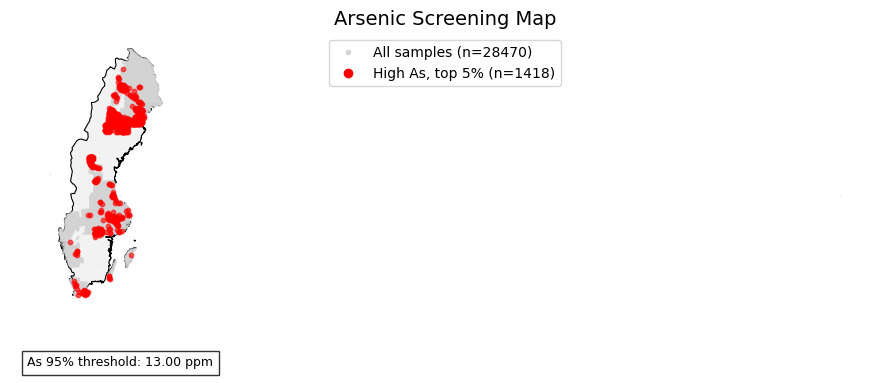

In [15]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# -----------------------------
# Arsenic map
# -----------------------------

fig, ax = plt.subplots(figsize=(9, 11))

sweden.plot(ax=ax, edgecolor="black", facecolor="#f2f2f2", linewidth=0.8)

df_clean.plot(ax=ax, color="lightgrey", markersize=0.5, alpha=0.25)

as_high = df_markgeodata[df_markgeodata["as_hotspot"]]

as_high.plot(ax=ax, color="red", markersize=10, alpha=0.6)

legend_elements = [
    mlines.Line2D([0], [0], marker="o", color="w",
                  label=f"All samples (n={len(df_clean)})",
                  markerfacecolor="lightgrey", markersize=5),

    mlines.Line2D([0], [0], marker="o", color="w",
                  label=f"High As, top 5% (n={len(as_high)})",
                  markerfacecolor="red", markersize=8)
]

ax.legend(handles=legend_elements, loc="upper center")
ax.set_title("Arsenic Screening Map", fontsize=14)
ax.set_axis_off()

ax.text(
    0.02, 0.02,
    f"As 95% threshold: {as_threshold:.2f} ppm",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
)

plt.tight_layout()

fig.savefig(
    r"C:/Projects/GeoChem-DataLab/results/arsenic_screening_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:

# -----------------------------
# Uranium map
# -----------------------------

fig, ax = plt.subplots(figsize=(9, 11))

sweden.plot(ax=ax, edgecolor="black", facecolor="#f2f2f2", linewidth=0.8)

df_clean.plot(ax=ax, color="lightgrey", markersize=0.5, alpha=0.25)

u_high = df_markgeodata[df_markgeodata["u_hotspot"]]

u_high.plot(ax=ax, color="blue", markersize=10, alpha=0.6)

legend_elements = [
    mlines.Line2D([0], [0], marker="o", color="w",
                  label=f"All samples (n={len(df_clean)})",
                  markerfacecolor="lightgrey", markersize=5),

    mlines.Line2D([0], [0], marker="o", color="w",
                  label=f"High U, top 5% (n={len(u_high)})",
                  markerfacecolor="blue", markersize=8)
]

ax.legend(handles=legend_elements, loc="upper center")
ax.set_title("Uranium Screening Map", fontsize=14)
ax.set_axis_off()

ax.text(
    0.02, 0.02,
    f"U 95% threshold: {u_threshold:.2f} ppm",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
)

plt.tight_layout()

fig.savefig(
    r"C:/Projects/GeoChem-DataLab/results/uranium_screening_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

KeyError: 'u_hotspot'

In [8]:
df_markgeodata.head()

,unikt_id,ns,ew,as_ppm,fe_ppm,ca_ppm,al_ppm,u_ppm,geometry,as_risk,u_risk,as_hotspot,u_hotspot,priority
1,"XX00.05001.Morän finfraktion (< 0,063 mm)",6426662.0,341104.0,2.0,11431.0,1276.0,9528.0,1.6,POINT (341104 6426662),Low,Low,False,False,Background
2,"XX00.05002.Morän finfraktion (< 0,063 mm)",6424548.0,341066.0,1.5,10501.0,2430.0,7855.0,1.6,POINT (341066 6424548),Low,Low,False,False,Background
3,"XX00.05003.Morän finfraktion (< 0,063 mm)",6422304.0,341028.0,1.3,14749.0,1216.0,9055.0,2.2,POINT (341028 6422304),Low,Low,False,False,Background
4,"XX00.05004.Morän finfraktion (< 0,063 mm)",6428703.0,343978.0,1.2,5063.0,1736.0,6322.0,0.9,POINT (343978 6428703),Low,Low,False,False,Background
5,"XX00.05005.Morän finfraktion (< 0,063 mm)",6426516.0,343613.0,1.6,9327.0,2374.0,6468.0,1.6,POINT (343613 6426516),Low,Low,False,False,Background
